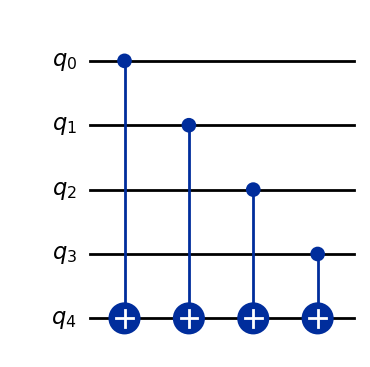

In [28]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(5)
for i in range(4):
    qc.cx(i,4)
qc.draw(output = "mpl")
oracle = qc.to_gate(label = "Parity")
new = QuantumCircuit(5)
new.append(oracle,[0,1,2,3,4])
new.draw(output="mpl")
state = Statevector.from_instruction(new)
display(state.draw('latex'))

In [4]:
def parity(x1,x2,x3,x4):
    return x1^x2^x3^x4
count_0 = 0
for x1 in range (2):
    for x2 in range (2):
        for x3 in range (2):
            for x4 in range (2):
                if parity(x1,x2,x3,x4) == 0:
                    count_0 +=1
if count_0 == 8:
    print("balanced")
elif count_0 == 0 or count_0 == 16:
    print("constant")
else:
    print("none")

balanced


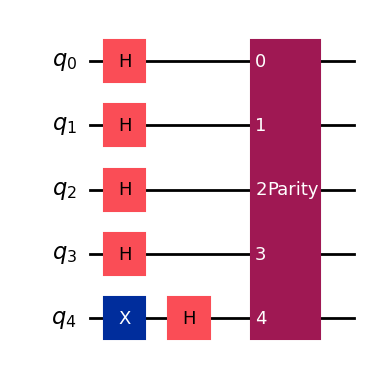

<IPython.core.display.Latex object>

In [16]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
qc = QuantumCircuit(5)
for i in range(4):
    qc.cx(i,4)
oracle = qc.to_gate(label = "Parity")
ckt = QuantumCircuit(5)
for i in range(4):
    ckt.h(i)
ckt.x(4)
ckt.h(4)
ckt.append(oracle, [0,1,2,3,4])
state = Statevector.from_instruction(ckt)
display(ckt.draw(output = "mpl"))
display(state.draw("latex"))

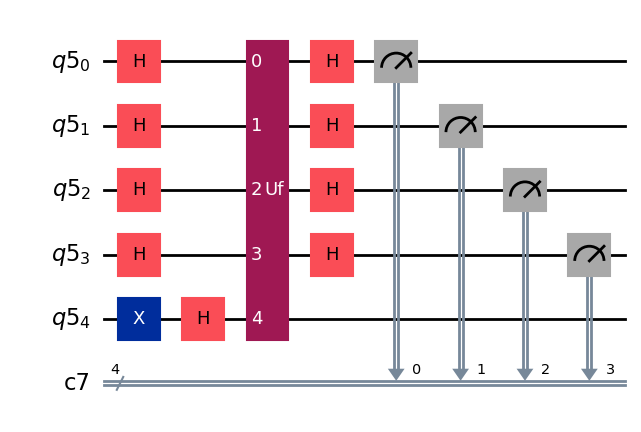

balanced


In [26]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
qc = QuantumCircuit(5)
c = ClassicalRegister(4)
q = QuantumRegister(5)
for i in range(4):
    qc.cx(i,4)
oracle = qc.to_gate(label = "Uf")
ckt = QuantumCircuit(q,c)
ckt.x(4)
for i in range(5):
    ckt.h(i)
ckt.append(oracle, [0,1,2,3,4])
for i in range(4):
    ckt.h(i)
    ckt.measure(i,c[i])
display(ckt.draw(output="mpl"))
counter = 0
for i in range(4):
    if c[i] == 0:
        counter+=1
if counter == 4:
    print("constant")
elif counter==0:
    print("balanced")

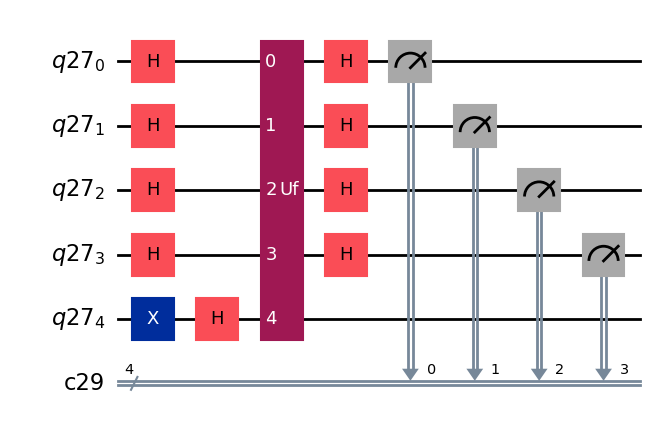

{'1011': 1024}


In [49]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
qc = QuantumCircuit(5)
qc.cx(0,4)
qc.cx(1,4)
qc.cx(3,4)
oracle = qc.to_instruction(label = "Uf")
c = ClassicalRegister(4)
q = QuantumRegister(5)
ckt = QuantumCircuit(q, c)
ckt.x(4)
ckt.h(4)
for i in range(4):
    ckt.h(i)
ckt.append(oracle, [0,1,2,3,4])
for i in range(4):
    ckt.h(i)
for i in range(4):
    ckt.measure(i, c[i])
display(ckt.draw(output="mpl"))
ckt = ckt.decompose()
sim = AerSimulator()
result = sim.run(ckt, shots=1024).result()
counts = result.get_counts()
print(counts)